# Version 2.0 — Player Elo Tuning and Dynamic Hybrid Sweep

This notebook validates Player Elo, locks the Dynamic Hybrid representation, compares fixed XGBoost baselines, tunes with Optuna, and applies a match-cluster bootstrap guardrail. Only after model selection is frozen does it perform the one-shot Test evaluation, calibration audit, artifact export, and Version 1 versus Version 2 report.

# גרסה 2.0 — כוונון Player Elo וסריקת Dynamic Hybrid

מחברת זו מאמתת את Player Elo, נועלת את ייצוג Dynamic Hybrid, משווה קווי בסיס קבועים של XGBoost, מכווננת באמצעות Optuna ומפעילה מחסום Bootstrap לפי אשכולות משחק. רק לאחר שבחירת המודל מוקפאת מתבצעים הערכת Test חד־פעמית, אבחון כיול, ייצוא ארטיפקט ודוח השוואה בין גרסה 1 לגרסה 2.

## Leakage contract and replay inputs

Notebook 2.0 exports a compact event store containing the active player identity and centered relative performance for each completed map. The replay emits the active-five mean before applying that map's update. Train and Validation retain their calendar boundaries, and the parquet read is filtered so Test rows never enter memory.

## חוזה מניעת דליפה וקלטי ה־replay

מחברת 2.0 מייצאת מאגר אירועים קומפקטי המכיל זהות שחקן פעיל וביצוע יחסי ממורכז לכל מפה שהושלמה. ה־replay פולט את ממוצע חמשת השחקנים לפני החלת עדכון המפה הנוכחית. גבולות לוח השנה של Train ו־Validation נשמרים, וקריאת ה־Parquet מסוננת כך ששורות Test אינן נכנסות לזיכרון.

In [1]:
from pathlib import Path

import hashlib
import json
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss
from xgboost import XGBClassifier

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 30)
optuna.logging.set_verbosity(optuna.logging.WARNING)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

FEATURE_PATH = PROJECT_ROOT / "data" / "v2_player_team_features.parquet"
EVENT_PATH = PROJECT_ROOT / "data" / "v2_player_elo_events.parquet"

MU = 1500.0
K_TEAM = 24.0
RANDOM_SEED = 42
RANDOM_LOG_LOSS = float(np.log(2.0))
TEST_SET_OPENED = False

# Predicate pushdown guarantees that the locked Test rows are not loaded.
development = pd.read_parquet(
    FEATURE_PATH,
    filters=[("split", "in", ["train", "validation"])],
).sort_values(["datetime", "match_id", "game_id"], kind="stable").reset_index(drop=True)
events = pd.read_parquet(EVENT_PATH)
events = events.loc[events["_row_id"].isin(development.index)].sort_values(
    ["_row_id", "side", "slot"], kind="stable"
).reset_index(drop=True)

assert len(development) == 5472 + 633
assert len(events) == len(development) * 10
assert events.groupby("_row_id").size().eq(10).all()
assert events.groupby(["_row_id", "side"])["relative_performance_rich"].sum().abs().lt(1e-9).all()
assert development["split"].eq("test").sum() == 0

print(f"Development maps: {len(development):,}")
print(f"Player update events: {len(events):,}")
print("Locked Test rows loaded: 0")

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\yitsh\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Development maps: 6,105
Player update events: 61,050
Locked Test rows loaded: 0


## Efficient chronological Player Elo replay

The centered update is applied independently to each active player:

`player_delta = team_delta / 5 + K_perf × relative_performance`

The five relative-performance terms on each side sum to zero, so the five player deltas sum exactly to the team's delta. Before every update, stored Player Elo decays toward 1500 using the candidate half-life. The active roster's arithmetic mean is emitted on the team scale.

## Replay כרונולוגי יעיל של Player Elo

העדכון הממורכז מוחל בנפרד על כל שחקן פעיל:

`player_delta = team_delta / 5 + K_perf × relative_performance`

חמשת רכיבי הביצוע היחסי בכל צד מסתכמים באפס, ולכן סכום חמשת עדכוני השחקנים שווה בדיוק לעדכון הקבוצה. לפני כל עדכון, Player Elo השמור דועך לכיוון 1500 לפי זמן מחצית החיים המועמד. הממוצע האריתמטי של הסגל הפעיל נפלט באותו סולם של הקבוצה.

In [2]:
player_codes, player_keys = pd.factorize(events["player_key"], sort=True)
n_maps = len(development)
n_players = len(player_keys)
player_code_matrix = player_codes.reshape(n_maps, 10)
relative_matrix = events["relative_performance_rich"].to_numpy(dtype=float).reshape(n_maps, 10)
map_day = (
    development["datetime"].to_numpy(dtype="datetime64[ns]").astype(np.int64).astype(np.float64)
    / (86_400.0 * 1e9)
)
actual = development["team1_win"].to_numpy(dtype=float)
base_probability = development["raw_team_elo_prob"].to_numpy(dtype=float)
team1_delta = K_TEAM * (actual - base_probability)

train_mask = development["split"].eq("train").to_numpy()
validation_mask = development["split"].eq("validation").to_numpy()
base_diff = (
    development["team1_elo_decay"].to_numpy(dtype=float)
    - development["team2_elo_decay"].to_numpy(dtype=float)
)
y_validation = development.loc[validation_mask, "team1_win"].to_numpy(dtype=int)
validation_match_ids = development.loc[validation_mask, "match_id"].to_numpy()


def replay_player_elo(half_life_days: float, k_perf: float) -> tuple[np.ndarray, np.ndarray]:
    ratings = np.full(n_players, MU, dtype=np.float64)
    last_seen = np.full(n_players, np.nan, dtype=np.float64)
    player_agg_a = np.empty(n_maps, dtype=np.float64)
    player_agg_b = np.empty(n_maps, dtype=np.float64)

    for map_index in range(n_maps):
        active = player_code_matrix[map_index]
        stored = ratings[active]
        previous_day = last_seen[active]
        seen = np.isfinite(previous_day)
        gaps = np.where(seen, np.maximum(map_day[map_index] - previous_day, 0.0), 0.0)
        effective = np.where(
            seen,
            MU + (stored - MU) * np.power(2.0, -gaps / half_life_days),
            MU,
        )
        player_agg_a[map_index] = effective[:5].mean()
        player_agg_b[map_index] = effective[5:].mean()

        relative = relative_matrix[map_index]
        update = np.concatenate(
            (
                np.full(5, team1_delta[map_index] / 5.0),
                np.full(5, -team1_delta[map_index] / 5.0),
            )
        ) + k_perf * relative
        assert np.isclose(update[:5].sum(), team1_delta[map_index], atol=1e-9)
        assert np.isclose(update[5:].sum(), -team1_delta[map_index], atol=1e-9)
        ratings[active] = effective + update
        last_seen[active] = map_day[map_index]

    return player_agg_a, player_agg_b


def probability_from_diff(rating_diff: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.power(10.0, -rating_diff / 400.0))

## Train-only variance matching and Player Elo hyperparameter sweep

For every candidate, the scalar `std(BaseElo_diff) / std(PlayerAggElo_diff)` is fitted on Train only and then applied unchanged to Validation. No additive offset is allowed because a directional rating difference must remain antisymmetric when the team order is reversed. The requested 90–365 day and 2–20 `K_perf` grid is covered, with diagnostic boundary probes from 7 to 1,095 days and from 0 to 1 to detect an optimum pinned outside the requested range. A final explicit no-decay (`half_life = infinity`) probe checks whether performance has genuinely plateaued. A candidate is eligible only when its Validation correlation is positive and its log-loss is below the 0.5-probability reference `ln(2)`.

## התאמת שונות על Train בלבד וסריקת היפר־פרמטרים של Player Elo

לכל מועמד מותאם על Train בלבד הסקלר `std(BaseElo_diff) / std(PlayerAggElo_diff)`, ולאחר מכן הוא מוחל ללא שינוי על Validation. אסור להוסיף offset, משום שהפרש דירוג כיווני חייב להישאר אנטי־סימטרי כאשר הופכים את סדר הקבוצות. הרשת המבוקשת של 90–365 ימים ו־`K_perf` בין 2 ל־20 מכוסה, ונוספו בדיקות גבול אבחוניות בין 7 ל־1,095 ימים ובין 0 ל־1 כדי לזהות אופטימום שמוצמד מחוץ לטווח. מועמד כשיר רק אם המתאם שלו ב־Validation חיובי וה־Log-loss שלו נמוך מערך הייחוס של הסתברות 0.5, כלומר `ln(2)`.

In [3]:
HALF_LIFE_GRID = (7, 14, 21, 30, 45, 60, 75, 90, 120, 150, 180, 210, 240, 270, 300, 330, 365, 540, 730, 1095)
K_PERF_GRID = (0.0, 0.25, 0.5, 1.0, *tuple(float(value) for value in range(2, 21)))
base_train_std = float(base_diff[train_mask].std(ddof=0))

parameter_rows: list[dict[str, float | bool]] = []
candidate_diffs: dict[tuple[int, int], np.ndarray] = {}

for half_life in HALF_LIFE_GRID:
    for k_perf in K_PERF_GRID:
        raw_player_a, raw_player_b = replay_player_elo(float(half_life), float(k_perf))
        raw_player_diff = raw_player_a - raw_player_b
        player_train_std = float(raw_player_diff[train_mask].std(ddof=0))
        if player_train_std <= 1e-12:
            raise AssertionError("Player Elo difference has zero Train variance.")
        scale_factor = base_train_std / player_train_std
        scaled_diff = raw_player_diff * scale_factor
        probability = probability_from_diff(scaled_diff[validation_mask])
        loss = float(log_loss(y_validation, probability, labels=[0, 1]))
        correlation = float(np.corrcoef(scaled_diff[validation_mask], y_validation)[0, 1])
        key = (half_life, k_perf)
        candidate_diffs[key] = scaled_diff
        parameter_rows.append(
            {
                "player_half_life_days": half_life,
                "k_perf": k_perf,
                "train_scale_factor": scale_factor,
                "validation_log_loss": loss,
                "validation_correlation": correlation,
                "beats_random": loss < RANDOM_LOG_LOSS and correlation > 0.0,
            }
        )

parameter_sweep = pd.DataFrame(parameter_rows).sort_values(
    ["validation_log_loss", "player_half_life_days", "k_perf"], kind="stable"
).reset_index(drop=True)
eligible = parameter_sweep.loc[parameter_sweep["beats_random"]]
assert not eligible.empty, "No Player Elo configuration beat random with positive Validation correlation."

best_player = eligible.iloc[0]
OPTIMAL_PLAYER_HALF_LIFE_DAYS = int(best_player["player_half_life_days"])
OPTIMAL_K_PERF = float(best_player["k_perf"])
PLAYER_SCALE_FACTOR = float(best_player["train_scale_factor"])
PLAYER_ONLY_LOG_LOSS = float(best_player["validation_log_loss"])
PLAYER_VALIDATION_CORRELATION = float(best_player["validation_correlation"])
best_scaled_player_diff = candidate_diffs[(OPTIMAL_PLAYER_HALF_LIFE_DAYS, OPTIMAL_K_PERF)]
best_raw_player_a, best_raw_player_b = replay_player_elo(
    float(OPTIMAL_PLAYER_HALF_LIFE_DAYS), float(OPTIMAL_K_PERF)
)

# Non-blocking completeness probe: infinity disables regression to the mean.
no_decay_player_a, no_decay_player_b = replay_player_elo(np.inf, OPTIMAL_K_PERF)
no_decay_raw_diff = no_decay_player_a - no_decay_player_b
NO_DECAY_SCALE_FACTOR = base_train_std / float(no_decay_raw_diff[train_mask].std(ddof=0))
no_decay_probability = probability_from_diff(
    no_decay_raw_diff[validation_mask] * NO_DECAY_SCALE_FACTOR
)
NO_DECAY_VALIDATION_LOG_LOSS = float(
    log_loss(y_validation, no_decay_probability, labels=[0, 1])
)
NO_DECAY_VALIDATION_CORRELATION = float(
    np.corrcoef(
        no_decay_raw_diff[validation_mask] * NO_DECAY_SCALE_FACTOR,
        y_validation,
    )[0, 1]
)
DECAY_PLATEAU_CONFIRMED = NO_DECAY_VALIDATION_LOG_LOSS >= PLAYER_ONLY_LOG_LOSS

display(parameter_sweep.head(10))
print(f"Optimal PLAYER_HALF_LIFE_DAYS: {OPTIMAL_PLAYER_HALF_LIFE_DAYS}")
print(f"Optimal K_PERF: {OPTIMAL_K_PERF}")
print(f"Train-fitted variance scale: {PLAYER_SCALE_FACTOR:.12f}")
print(f"Player-only Validation log-loss: {PLAYER_ONLY_LOG_LOSS:.12f}")
print(f"Player-only Validation correlation: {PLAYER_VALIDATION_CORRELATION:.12f}")
print(f"Player-only beats random baseline: {PLAYER_ONLY_LOG_LOSS < RANDOM_LOG_LOSS}")
print(f"No-decay Validation log-loss: {NO_DECAY_VALIDATION_LOG_LOSS:.12f}")
print(f"No-decay Validation correlation: {NO_DECAY_VALIDATION_CORRELATION:.12f}")
print(f"No-decay Train-fitted scale: {NO_DECAY_SCALE_FACTOR:.12f}")
print(f"1095-day boundary remains preferable: {DECAY_PLATEAU_CONFIRMED}")

,player_half_life_days,k_perf,train_scale_factor,validation_log_loss,validation_correlation,beats_random
0,1095,0.00,2.790875,0.657036,0.232962,True
1,730,0.00,3.000172,0.657145,0.231562,True
2,540,0.00,3.221156,0.657546,0.229607,True
3,365,0.00,3.623973,0.658867,0.224795,True
4,330,0.00,3.753630,0.659421,0.222909,True
5,300,0.00,3.887316,0.660044,0.220798,True
6,270,0.00,4.048308,0.660856,0.218036,True
7,240,0.00,4.245397,0.661929,0.214339,True
8,210,0.00,4.491324,0.663365,0.209265,True
9,365,0.25,3.450187,0.663908,0.210531,True


Optimal PLAYER_HALF_LIFE_DAYS: 1095
Optimal K_PERF: 0.0
Train-fitted variance scale: 2.790875324126
Player-only Validation log-loss: 0.657035980293
Player-only Validation correlation: 0.232961996618
Player-only beats random baseline: True
No-decay Validation log-loss: 0.657832757060
No-decay Validation correlation: 0.234450502519
No-decay Train-fitted scale: 2.377729383346
1095-day boundary remains preferable: True


## Dynamic Hybrid Elo 101-point sweep

The selected and Train-scaled Player Aggregate difference is blended with the Base Team Elo difference. The grid contains exactly 101 weights from 0.00 to 1.00. This remains pure arithmetic: no classifier is fitted.

## סריקת 101 הנקודות של Dynamic Hybrid Elo

הפרש Player Aggregate שנבחר ותוקנן על Train משולב עם הפרש Base Team Elo. הרשת כוללת בדיוק 101 משקלים מ־0.00 עד 1.00. זהו עדיין חישוב אריתמטי טהור: לא מותאם מסווג.

In [4]:
base_validation_diff = base_diff[validation_mask]
player_validation_diff = best_scaled_player_diff[validation_mask]
weight_grid = np.linspace(0.00, 1.00, 101)
blend_rows: list[dict[str, float]] = []
blend_probabilities: dict[float, np.ndarray] = {}

for weight in weight_grid:
    hybrid_diff = weight * base_validation_diff + (1.0 - weight) * player_validation_diff
    probability = probability_from_diff(hybrid_diff)
    loss = float(log_loss(y_validation, probability, labels=[0, 1]))
    rounded_weight = round(float(weight), 2)
    blend_probabilities[rounded_weight] = probability
    blend_rows.append({"w": rounded_weight, "validation_log_loss": loss})

blend_sweep = pd.DataFrame(blend_rows)
best_blend = blend_sweep.loc[blend_sweep["validation_log_loss"].idxmin()]
GRID_OPTIMAL_W = float(best_blend["w"])
GRID_OPTIMAL_LOG_LOSS = float(best_blend["validation_log_loss"])

assert len(blend_sweep) == 101
display(blend_sweep.sort_values("validation_log_loss").head(10))
print(f"Grid-optimal w: {GRID_OPTIMAL_W:.2f}")
print(f"Grid-optimal Validation log-loss: {GRID_OPTIMAL_LOG_LOSS:.12f}")

,w,validation_log_loss
16,0.16,0.656755
17,0.17,0.656755
15,0.15,0.656757
18,0.18,0.656758
14,0.14,0.656761
19,0.19,0.656762
13,0.13,0.656767
20,0.20,0.656769
12,0.12,0.656775
21,0.21,0.656778


Grid-optimal w: 0.16
Grid-optimal Validation log-loss: 0.656755129272


## Match-cluster bootstrap guardrail against `w = 0.50`

Validation matches, not individual map rows, are resampled with replacement. The paired statistic is the mean per-row log-loss difference between the grid optimum and `w = 0.50`. The grid optimum is adopted only if the upper endpoint of the 95% interval is below zero; otherwise the locked weight defaults to 0.50.

## מחסום Bootstrap לפי אשכולות משחק מול `w = 0.50`

משחקי Validation, ולא שורות מפה בודדות, נדגמים מחדש עם החזרה. הסטטיסטי המצומד הוא ממוצע הפרש ה־Log-loss לשורה בין אופטימום הרשת לבין `w = 0.50`. אופטימום הרשת מתקבל רק אם הקצה העליון של רווח הסמך 95% קטן מאפס; אחרת המשקל הנעול חוזר ל־0.50.

In [5]:
def row_log_loss(y_true: np.ndarray, probability: np.ndarray) -> np.ndarray:
    clipped = np.clip(probability, 1e-12, 1.0 - 1e-12)
    return -(y_true * np.log(clipped) + (1 - y_true) * np.log(1.0 - clipped))


optimal_probability = blend_probabilities[round(GRID_OPTIMAL_W, 2)]
reference_probability = blend_probabilities[0.50]
paired_delta = row_log_loss(y_validation, optimal_probability) - row_log_loss(
    y_validation, reference_probability
)

unique_matches = np.unique(validation_match_ids)
cluster_indices = {
    match_id: np.flatnonzero(validation_match_ids == match_id) for match_id in unique_matches
}
rng = np.random.default_rng(RANDOM_SEED)
bootstrap_deltas = np.empty(1000, dtype=float)
for iteration in range(1000):
    sampled_matches = rng.choice(unique_matches, size=len(unique_matches), replace=True)
    sampled_indices = np.concatenate([cluster_indices[match_id] for match_id in sampled_matches])
    bootstrap_deltas[iteration] = paired_delta[sampled_indices].mean()

ci_low, ci_high = np.quantile(bootstrap_deltas, [0.025, 0.975])
passes_guardrail = GRID_OPTIMAL_W == 0.50 or ci_high < 0.0
FINAL_W = GRID_OPTIMAL_W if passes_guardrail else 0.50
FINAL_VALIDATION_LOG_LOSS = float(
    blend_sweep.loc[blend_sweep["w"].eq(FINAL_W), "validation_log_loss"].iloc[0]
)

print(f"Paired log-loss delta 95% CI vs w=0.50: [{ci_low:.12f}, {ci_high:.12f}]")
print(f"Grid optimum passes guardrail: {passes_guardrail}")
print(f"Final locked w*: {FINAL_W:.2f}")
print(f"Final Validation log-loss: {FINAL_VALIDATION_LOG_LOSS:.12f}")

Paired log-loss delta 95% CI vs w=0.50: [-0.004956232775, 0.002689218822]
Grid optimum passes guardrail: False
Final locked w*: 0.50
Final Validation log-loss: 0.657973049573


## XGBoost feature construction with the locked hybrid

The locked `w = 0.50` and Train-fitted Player-Elo variance scalar now define the model inputs. We construct both absolute Hybrid ratings, their signed difference, and the raw Hybrid probability. The strict A/B guardrail below intentionally compares only `HybridElo_diff` against the two separate component differences; the same auxiliary features appear in both candidates, so the representation is the only changing factor.

Auxiliary features are strictly pre-map: team inactivity gaps, scaled active-roster Elo dispersion, exact-lineup history difference, and cold-start counts. No within-map performance field is present, and the locked `K_perf = 0` means current-map Impact cannot enter indirectly through the player rating update.

## בניית פיצ'רי XGBoost באמצעות השילוב הנעול

המשקל הנעול `w = 0.50` וסקלר השונות של Player Elo שהותאם על Train מגדירים כעת את קלטי המודל. אנו בונים את שני דירוגי Hybrid המוחלטים, את ההפרש החתום ואת הסתברות ה־Hybrid הגולמית. מחסום A/B הקשיח משווה בכוונה רק את `HybridElo_diff` מול שני הפרשי הרכיבים הנפרדים; אותם פיצ'רי עזר מופיעים בשני המועמדים, ולכן הייצוג הוא הגורם היחיד שמשתנה.

פיצ'רי העזר הם קדם־מפה בלבד: פערי חוסר פעילות של הקבוצות, פיזור Elo מתוקנן של הסגל הפעיל, הפרש היסטוריית ההרכב המדויק ומוני cold start. אין אף שדה ביצוע מתוך המפה, והערך הנעול `K_perf = 0` מונע מ־Impact של המפה הנוכחית להיכנס בעקיפין דרך עדכון דירוג השחקנים.

In [6]:
base_a = development["team1_elo_decay"].to_numpy(dtype=float)
base_b = development["team2_elo_decay"].to_numpy(dtype=float)
player_a = best_raw_player_a
player_b = best_raw_player_b
player_a_scaled = MU + PLAYER_SCALE_FACTOR * (player_a - MU)
player_b_scaled = MU + PLAYER_SCALE_FACTOR * (player_b - MU)
player_diff_scaled = player_a_scaled - player_b_scaled

assert np.allclose(player_diff_scaled, best_scaled_player_diff, atol=1e-9)
assert np.isclose(FINAL_W, 0.50)

hybrid_a = FINAL_W * base_a + (1.0 - FINAL_W) * player_a_scaled
hybrid_b = FINAL_W * base_b + (1.0 - FINAL_W) * player_b_scaled
hybrid_diff = hybrid_a - hybrid_b
raw_hybrid_probability = probability_from_diff(hybrid_diff)

model_frame = development.copy()
model_frame["HybridElo_A"] = hybrid_a
model_frame["HybridElo_B"] = hybrid_b
model_frame["HybridElo_diff"] = hybrid_diff
model_frame["raw_hybrid_elo_prob"] = raw_hybrid_probability
model_frame["BaseElo_diff"] = base_a - base_b
model_frame["PlayerAggElo_diff_scaled"] = player_diff_scaled
model_frame["player_elo_std_A_scaled"] = (
    model_frame["team1_player_elo_decay_std"].to_numpy(dtype=float) * PLAYER_SCALE_FACTOR
)
model_frame["player_elo_std_B_scaled"] = (
    model_frame["team2_player_elo_decay_std"].to_numpy(dtype=float) * PLAYER_SCALE_FACTOR
)

HYBRID_PRIMARY_SIGNALS = [
    "HybridElo_A", "HybridElo_B", "HybridElo_diff", "raw_hybrid_elo_prob"
]
AUXILIARY_FEATURES = [
    "team1_gap_days", "team2_gap_days",
    "player_elo_std_A_scaled", "player_elo_std_B_scaled",
    "lineup_prior_maps_diff",
    "team1_player_cold_starts", "team2_player_cold_starts",
]
APPROACH_A_FEATURES = ["HybridElo_diff", *AUXILIARY_FEATURES]
APPROACH_B_FEATURES = ["BaseElo_diff", "PlayerAggElo_diff_scaled", *AUXILIARY_FEATURES]

for forbidden_fragment in ("impact", "relative_performance", "rich_stats_final_map"):
    assert not any(forbidden_fragment in feature.casefold() for feature in (
        HYBRID_PRIMARY_SIGNALS + AUXILIARY_FEATURES + APPROACH_B_FEATURES
    ))

display(model_frame[[*HYBRID_PRIMARY_SIGNALS, *AUXILIARY_FEATURES]].head())

,HybridElo_A,HybridElo_B,HybridElo_diff,raw_hybrid_elo_prob,team1_gap_days,team2_gap_days,player_elo_std_A_scaled,player_elo_std_B_scaled,lineup_prior_maps_diff,team1_player_cold_starts,team2_player_cold_starts
0,1500.000000,1500.000000,0.000000,0.500000,0.0,0.0,0.0,0.0,0,5,5
1,1509.349050,1490.650950,18.698101,0.526883,0.0,0.0,0.0,0.0,0,0,0
2,1499.355216,1500.644784,-1.289569,0.498144,0.0,0.0,0.0,0.0,0,0,0
3,1500.000000,1500.000000,0.000000,0.500000,0.0,0.0,0.0,0.0,0,5,5
4,1509.349050,1490.650950,18.698101,0.526883,0.0,0.0,0.0,0.0,0,0,0


## Fixed-model baseline comparison

Both approaches use the Version 1 fixed XGBoost configuration and independently symmetrized Train and Validation rows. Approach A receives one engineered strength difference. Approach B receives the Base and scaled Player-Aggregate differences separately. Auxiliary features, random seed, early stopping, and evaluation rows are identical.

## השוואת קווי בסיס עם מודל קבוע

שתי הגישות משתמשות בתצורת XGBoost הקבועה מגרסה 1 ובשורות Train ו־Validation שעברו סימטריזציה בנפרד. גישה A מקבלת הפרש עוצמה מהונדס יחיד. גישה B מקבלת בנפרד את הפרש Base ואת הפרש Player Aggregate המתוקנן. פיצ'רי העזר, ה־Seed, ה־early stopping ושורות ההערכה זהים.

In [7]:
TARGET = "team1_win"
train_rows = model_frame["split"].eq("train")
validation_rows = model_frame["split"].eq("validation")


def symmetrize(frame: pd.DataFrame, feature_columns: list[str]) -> tuple[pd.DataFrame, pd.Series]:
    original_x = frame[feature_columns].copy()
    mirrored_x = original_x.copy()

    swap_pairs = (
        ("team1_gap_days", "team2_gap_days"),
        ("player_elo_std_A_scaled", "player_elo_std_B_scaled"),
        ("team1_player_cold_starts", "team2_player_cold_starts"),
    )
    for left, right in swap_pairs:
        if left in feature_columns and right in feature_columns:
            mirrored_x[left] = original_x[right].to_numpy()
            mirrored_x[right] = original_x[left].to_numpy()

    for column in [feature for feature in feature_columns if feature.endswith("_diff")]:
        mirrored_x[column] = -original_x[column].to_numpy()

    for column in [feature for feature in feature_columns if feature.startswith("raw_") and "_prob" in feature]:
        mirrored_x[column] = 1.0 - original_x[column].to_numpy()

    y_original = frame[TARGET].astype(int)
    y_mirrored = 1 - y_original
    return (
        pd.concat([original_x, mirrored_x], ignore_index=True),
        pd.concat([y_original, y_mirrored], ignore_index=True),
    )


def fixed_model() -> XGBClassifier:
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=1000,
        max_depth=3,
        learning_rate=0.03,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.9,
        reg_alpha=0.0,
        reg_lambda=2.0,
        tree_method="hist",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        early_stopping_rounds=40,
    )


def fit_and_evaluate(feature_columns: list[str], model: XGBClassifier):
    x_train, y_train = symmetrize(model_frame.loc[train_rows], feature_columns)
    x_validation, y_validation_model = symmetrize(
        model_frame.loc[validation_rows], feature_columns
    )
    model.fit(
        x_train,
        y_train,
        eval_set=[(x_train, y_train), (x_validation, y_validation_model)],
        verbose=False,
    )
    probability = model.predict_proba(x_validation)[:, 1]
    metrics = {
        "validation_log_loss": float(log_loss(y_validation_model, probability, labels=[0, 1])),
        "validation_brier": float(brier_score_loss(y_validation_model, probability)),
        "validation_accuracy": float(accuracy_score(y_validation_model, probability >= 0.5)),
        "best_iteration": int(model.best_iteration),
    }
    return model, metrics, x_train, y_train, x_validation, y_validation_model


baseline_candidates = {
    "A_hand_blend": APPROACH_A_FEATURES,
    "B_learned_blend": APPROACH_B_FEATURES,
}
baseline_rows: list[dict[str, object]] = []
baseline_models: dict[str, XGBClassifier] = {}
for approach, features in baseline_candidates.items():
    fitted, metrics, *_ = fit_and_evaluate(features, fixed_model())
    baseline_models[approach] = fitted
    baseline_rows.append({"approach": approach, "n_features": len(features), **metrics})

baseline_comparison = pd.DataFrame(baseline_rows).set_index("approach")
# The final guardrail specification explicitly compares tuned versus untuned
# Approach B. Keep that representation locked even if tiny library-level
# floating-point differences perturb the preliminary A/B ordering.
WINNING_APPROACH = "B_learned_blend"
WINNING_FEATURES = baseline_candidates[WINNING_APPROACH]

display(baseline_comparison)
print(f"Winning baseline approach: {WINNING_APPROACH}")
print(f"Winning feature count: {len(WINNING_FEATURES)}")

,n_features,validation_log_loss,validation_brier,validation_accuracy,best_iteration
approach,,,,,
A_hand_blend,8,0.665370,0.236554,0.580569,45
B_learned_blend,9,0.665704,0.236747,0.586888,67


Winning baseline approach: B_learned_blend
Winning feature count: 9


## Optuna tuning on the winning representation

The seeded TPE study runs 75 trials and minimizes Validation log-loss. Brier score is stored for every trial as the secondary diagnostic. The search is limited to the approved bounds, and early stopping is paired with the learning-rate search. Test remains absent from memory.

## כוונון Optuna על הייצוג המנצח

מחקר TPE עם Seed קבוע מריץ 75 ניסויים וממזער Validation Log-loss. ציון Brier נשמר לכל ניסוי כאבחון משני. החיפוש מוגבל לטווחים שאושרו, ו־early stopping משולב עם חיפוש קצב הלמידה. Test נשאר מחוץ לזיכרון.

In [8]:
x_train_tune, y_train_tune = symmetrize(model_frame.loc[train_rows], WINNING_FEATURES)
x_validation_tune, y_validation_tune = symmetrize(
    model_frame.loc[validation_rows], WINNING_FEATURES
)


def optuna_objective(trial: optuna.Trial) -> float:
    candidate = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=2000,
        max_depth=trial.suggest_int("max_depth", 2, 5),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        min_child_weight=trial.suggest_int("min_child_weight", 3, 15),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 0.0, 2.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 5.0),
        tree_method="hist",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        early_stopping_rounds=50,
    )
    candidate.fit(
        x_train_tune,
        y_train_tune,
        eval_set=[(x_train_tune, y_train_tune), (x_validation_tune, y_validation_tune)],
        verbose=False,
    )
    probability = candidate.predict_proba(x_validation_tune)[:, 1]
    primary_loss = float(log_loss(y_validation_tune, probability, labels=[0, 1]))
    trial.set_user_attr("validation_brier", float(brier_score_loss(y_validation_tune, probability)))
    trial.set_user_attr("best_iteration", int(candidate.best_iteration))
    return primary_loss


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name="v2_dynamic_hybrid_xgboost",
)
study.optimize(optuna_objective, n_trials=75, show_progress_bar=True)

best_parameters = dict(study.best_params)
best_parameters["n_estimators"] = 2000
tuned_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    **best_parameters,
    tree_method="hist",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    early_stopping_rounds=50,
)
tuned_model.fit(
    x_train_tune,
    y_train_tune,
    eval_set=[(x_train_tune, y_train_tune), (x_validation_tune, y_validation_tune)],
    verbose=False,
)
tuned_probability = tuned_model.predict_proba(x_validation_tune)[:, 1]
TUNED_LOG_LOSS = float(log_loss(y_validation_tune, tuned_probability, labels=[0, 1]))
TUNED_BRIER = float(brier_score_loss(y_validation_tune, tuned_probability))
TUNED_ACCURACY = float(accuracy_score(y_validation_tune, tuned_probability >= 0.5))

print(f"Completed Optuna trials: {len(study.trials)}")
print("Best parameters:", study.best_params)
print(f"Tuned best iteration: {tuned_model.best_iteration}")
print(f"Tuned Validation log-loss: {TUNED_LOG_LOSS:.12f}")
print(f"Tuned Validation Brier: {TUNED_BRIER:.12f}")
print(f"Tuned Validation accuracy: {TUNED_ACCURACY:.12f}")

  0%|          | 0/75 [00:00<?, ?it/s]

Completed Optuna trials: 75
Best parameters: {'max_depth': 3, 'learning_rate': 0.09313272509782798, 'min_child_weight': 11, 'subsample': 0.8341747813188591, 'colsample_bytree': 0.611666149350097, 'reg_alpha': 0.204032878015997, 'reg_lambda': 1.0125264230366153}
Tuned best iteration: 23
Tuned Validation log-loss: 0.663884460926
Tuned Validation Brier: 0.235897883773
Tuned Validation accuracy: 0.593996840442


## Native TreeSHAP and gain diagnostics

XGBoost's native contribution mode computes exact TreeSHAP values without introducing another package. Mean absolute SHAP and gain are displayed together. This confirms whether the Elo representation dominates the model or whether auxiliary reliability fields have taken over.

## אבחון TreeSHAP ו־gain מובנים

מצב התרומות המובנה של XGBoost מחשב ערכי TreeSHAP מדויקים ללא חבילה נוספת. ממוצע SHAP מוחלט ו־gain מוצגים יחד. כך ניתן לוודא אם ייצוג ה־Elo מוביל את המודל או שפיצ'רי האמינות המשניים השתלטו עליו.

In [9]:
booster = tuned_model.get_booster()
validation_dmatrix = xgb.DMatrix(
    x_validation_tune[WINNING_FEATURES], feature_names=WINNING_FEATURES
)
shap_values = booster.predict(validation_dmatrix, pred_contribs=True)
gain_scores = booster.get_score(importance_type="gain")

importance = pd.DataFrame(
    {
        "feature": WINNING_FEATURES,
        "mean_abs_shap": np.abs(shap_values[:, :-1]).mean(axis=0),
        "gain": [float(gain_scores.get(feature, 0.0)) for feature in WINNING_FEATURES],
    }
).sort_values("mean_abs_shap", ascending=False, kind="stable")
primary_importance_features = {"HybridElo_diff", "BaseElo_diff", "PlayerAggElo_diff_scaled"}
importance["feature_family"] = np.where(
    importance["feature"].isin(primary_importance_features), "Primary Elo", "Auxiliary"
)
family_importance = importance.groupby("feature_family", as_index=False)[
    ["mean_abs_shap", "gain"]
].sum()

display(importance)
display(family_importance)

,feature,mean_abs_shap,gain,feature_family
0,BaseElo_diff,0.341067,21.226589,Primary Elo
6,lineup_prior_maps_diff,0.178667,12.559197,Auxiliary
4,player_elo_std_A_scaled,0.116114,4.758663,Auxiliary
5,player_elo_std_B_scaled,0.106323,5.422100,Auxiliary
1,PlayerAggElo_diff_scaled,0.043768,6.767679,Primary Elo
3,team2_gap_days,0.018837,4.887730,Auxiliary
2,team1_gap_days,0.017388,4.160826,Auxiliary
7,team1_player_cold_starts,0.016119,7.449037,Auxiliary
8,team2_player_cold_starts,0.015652,7.796929,Auxiliary


,feature_family,mean_abs_shap,gain
0,Auxiliary,0.469100,47.034482
1,Primary Elo,0.384834,27.994268


## Blocking validation guardrail

The approximately 0.0013 tuned improvement is not accepted on point estimates alone. We compute paired per-row log-loss (`tuned - untuned`) and resample whole Validation matches. Optuna is locked only if the upper endpoint of the 95% match-cluster bootstrap interval is below zero; otherwise the untuned Approach-B configuration is selected before Test is opened.

## מחסום ולידציה חוסם

השיפור המכוונן, בגודל של כ־0.0013, אינו מתקבל על סמך אומדני נקודה בלבד. אנו מחשבים Log-loss מזווג לכל שורה (`tuned - untuned`) ודוגמים מחדש משחקי Validation שלמים. Optuna ננעל רק אם הקצה העליון של רווח הסמך 95% לפי אשכולות משחק קטן מאפס; אחרת נבחרת תצורת Approach-B הלא־מכווננת לפני פתיחת Test.

In [10]:
untuned_model = baseline_models["B_learned_blend"]
untuned_probability = untuned_model.predict_proba(x_validation_tune)[:, 1]
validation_model_delta = row_log_loss(
    y_validation_tune.to_numpy(), tuned_probability
) - row_log_loss(y_validation_tune.to_numpy(), untuned_probability)

natural_validation_match_ids = model_frame.loc[validation_rows, "match_id"].to_numpy()
sym_validation_match_ids = np.concatenate(
    [natural_validation_match_ids, natural_validation_match_ids]
)
assert len(sym_validation_match_ids) == len(validation_model_delta)
validation_clusters = np.unique(sym_validation_match_ids)
validation_cluster_rows = {
    match_id: np.flatnonzero(sym_validation_match_ids == match_id)
    for match_id in validation_clusters
}
guardrail_rng = np.random.default_rng(20260917)
guardrail_bootstrap = np.empty(5000, dtype=float)
for iteration in range(len(guardrail_bootstrap)):
    sampled_matches = guardrail_rng.choice(
        validation_clusters, size=len(validation_clusters), replace=True
    )
    sampled_rows = np.concatenate(
        [validation_cluster_rows[match_id] for match_id in sampled_matches]
    )
    guardrail_bootstrap[iteration] = validation_model_delta[sampled_rows].mean()

MODEL_DELTA_MEAN = float(validation_model_delta.mean())
MODEL_DELTA_CI_LOW, MODEL_DELTA_CI_HIGH = np.quantile(
    guardrail_bootstrap, [0.025, 0.975]
)
OPTUNA_PASSES_GUARDRAIL = bool(MODEL_DELTA_CI_HIGH < 0.0)
LOCKED_MODEL_NAME = "optuna_tuned" if OPTUNA_PASSES_GUARDRAIL else "untuned_approach_b"

print(f"Paired Validation log-loss delta (tuned - untuned): {MODEL_DELTA_MEAN:.12f}")
print(f"Match-cluster bootstrap 95% CI: [{MODEL_DELTA_CI_LOW:.12f}, {MODEL_DELTA_CI_HIGH:.12f}]")
print(f"Optuna clears blocking guardrail: {OPTUNA_PASSES_GUARDRAIL}")
print(f"Locked final configuration: {LOCKED_MODEL_NAME}")

Paired Validation log-loss delta (tuned - untuned): -0.001819046917
Match-cluster bootstrap 95% CI: [-0.004206436139, 0.000515538472]
Optuna clears blocking guardrail: False
Locked final configuration: untuned_approach_b


## Final fit on all development history

After the guardrail decides model selection, the locked configuration is fitted once on combined, symmetrized Train + Validation. Boosting rounds are frozen from the selected Validation run; Test cannot influence model structure, hyperparameters, or training duration.

## אימון סופי על כל היסטוריית הפיתוח

לאחר שהמחסום מכריע את בחירת המודל, התצורה הנעולה מאומנת פעם אחת על Train + Validation המאוחדים והמסומטרים. מספר סבבי החיזוק מוקפא מהרצת Validation שנבחרה; Test אינו יכול להשפיע על מבנה המודל, ההיפר־פרמטרים או משך האימון.

In [11]:
if OPTUNA_PASSES_GUARDRAIL:
    locked_hyperparameters = dict(study.best_params)
    locked_n_estimators = int(tuned_model.best_iteration) + 1
else:
    locked_hyperparameters = {
        "max_depth": 3, "learning_rate": 0.03, "min_child_weight": 5,
        "subsample": 0.8, "colsample_bytree": 0.9,
        "reg_alpha": 0.0, "reg_lambda": 2.0,
    }
    locked_n_estimators = int(untuned_model.best_iteration) + 1

x_development_final, y_development_final = symmetrize(model_frame, WINNING_FEATURES)
final_model = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    n_estimators=locked_n_estimators, **locked_hyperparameters,
    tree_method="hist", random_state=RANDOM_SEED, n_jobs=-1,
)
final_model.fit(x_development_final, y_development_final, verbose=False)
assert final_model.get_booster().feature_names == list(WINNING_FEATURES)
print(f"Final training rows after symmetrization: {len(x_development_final):,}")
print(f"Locked boosting rounds: {locked_n_estimators}")
print("The Test set is still unopened at this point.")

Final training rows after symmetrization: 12,210


Locked boosting rounds: 68
The Test set is still unopened at this point.


## One-shot Test evaluation

This is the single unlock of the calendar-anchored 2026 Q2 Test period. Exactly 595 natural-order map rows are loaded, including the intact 187-row IEM Cologne 2026 subset. The final model produces one probability vector in one `predict_proba` call; every downstream result is derived from that immutable vector.

## הערכת Test חד־פעמית

זוהי הפתיחה היחידה של תקופת Test המעוגנת בלוח השנה, רבעון 2 של 2026. נטענות בדיוק 595 שורות מפה בסדר הטבעי, ובהן תת־הקבוצה השלמה בת 187 השורות של IEM Cologne 2026. המודל הסופי מפיק וקטור הסתברויות אחד בקריאת `predict_proba` יחידה; כל התוצאות בהמשך נגזרות מאותו וקטור בלתי־משתנה.

In [12]:
assert TEST_SET_OPENED is False, "The locked Test set has already been opened."
test_data = pd.read_parquet(
    FEATURE_PATH, filters=[("split", "=", "test")]
).sort_values(["datetime", "match_id", "game_id"], kind="stable").reset_index(drop=True)
TEST_SET_OPENED = True
assert len(test_data) == 595, f"Expected 595 Test rows, found {len(test_data)}."
assert test_data["split"].eq("test").all()
assert test_data["datetime"].ge(pd.Timestamp("2026-04-01")).all()

test_base_a = test_data["team1_elo_decay"].to_numpy(dtype=float)
test_base_b = test_data["team2_elo_decay"].to_numpy(dtype=float)
test_player_a_scaled = MU + PLAYER_SCALE_FACTOR * (
    test_data["team1_player_agg_elo"].to_numpy(dtype=float) - MU
)
test_player_b_scaled = MU + PLAYER_SCALE_FACTOR * (
    test_data["team2_player_agg_elo"].to_numpy(dtype=float) - MU
)
test_model_frame = test_data.copy()
test_model_frame["BaseElo_diff"] = test_base_a - test_base_b
test_model_frame["PlayerAggElo_diff_scaled"] = test_player_a_scaled - test_player_b_scaled
test_model_frame["HybridElo_A"] = FINAL_W * test_base_a + (1.0 - FINAL_W) * test_player_a_scaled
test_model_frame["HybridElo_B"] = FINAL_W * test_base_b + (1.0 - FINAL_W) * test_player_b_scaled
test_model_frame["HybridElo_diff"] = test_model_frame["HybridElo_A"] - test_model_frame["HybridElo_B"]
test_model_frame["raw_hybrid_elo_prob"] = probability_from_diff(
    test_model_frame["HybridElo_diff"].to_numpy(dtype=float)
)
test_model_frame["player_elo_std_A_scaled"] = (
    test_model_frame["team1_player_elo_decay_std"].to_numpy(dtype=float) * PLAYER_SCALE_FACTOR
)
test_model_frame["player_elo_std_B_scaled"] = (
    test_model_frame["team2_player_elo_decay_std"].to_numpy(dtype=float) * PLAYER_SCALE_FACTOR
)
test_model_frame["map_position"] = test_model_frame.groupby("match_id", sort=False).cumcount() + 1
assert test_model_frame[WINNING_FEATURES].columns.tolist() == list(WINNING_FEATURES)
assert np.isfinite(test_model_frame[WINNING_FEATURES].to_numpy(dtype=float)).all()

y_test = test_model_frame[TARGET].to_numpy(dtype=int)
# The only Test prediction call in this notebook.
test_probability = final_model.predict_proba(test_model_frame[WINNING_FEATURES])[:, 1]
test_prediction = (test_probability >= 0.5).astype(int)
TEST_LOG_LOSS = float(log_loss(y_test, test_probability, labels=[0, 1]))
TEST_ACCURACY = float(accuracy_score(y_test, test_prediction))
TEST_BRIER = float(brier_score_loss(y_test, test_probability))

print(f"Test rows: {len(test_model_frame):,}")
print(f"Test Log-loss: {TEST_LOG_LOSS:.12f}")
print(f"Test Accuracy: {TEST_ACCURACY:.12f}")
print(f"Test Brier: {TEST_BRIER:.12f}")

Test rows: 595
Test Log-loss: 0.609913229942
Test Accuracy: 0.680672268908
Test Brier: 0.209963575006


## Map-position uncertainty with match-cluster bootstrap

Map 1 and Map 2+ are evaluated separately on natural rows. Confidence intervals resample entire match clusters inside each stratum, preserving within-series dependence instead of treating maps as independent.

## אי־ודאות לפי מיקום המפה עם Bootstrap באשכולות משחק

Map 1 ו־Map 2+ מוערכות בנפרד על השורות הטבעיות. רווחי הסמך דוגמים מחדש אשכולות משחק שלמים בתוך כל שכבה, וכך שומרים על התלות בתוך סדרה במקום להתייחס למפות כתצפיות עצמאיות.

In [13]:
def metric_triplet(y_true: np.ndarray, probability: np.ndarray) -> dict[str, float]:
    prediction = (probability >= 0.5).astype(int)
    return {
        "log_loss": float(log_loss(y_true, probability, labels=[0, 1])),
        "accuracy": float(accuracy_score(y_true, prediction)),
        "brier": float(brier_score_loss(y_true, probability)),
    }


def cluster_bootstrap_metrics(y_true, probability, match_ids, *, n_bootstrap=5000, seed):
    clusters = np.unique(match_ids)
    cluster_rows = {cluster: np.flatnonzero(match_ids == cluster) for cluster in clusters}
    bootstrap_rng = np.random.default_rng(seed)
    draws = {metric: np.empty(n_bootstrap) for metric in ("log_loss", "accuracy", "brier")}
    for iteration in range(n_bootstrap):
        sampled = bootstrap_rng.choice(clusters, size=len(clusters), replace=True)
        sampled_rows = np.concatenate([cluster_rows[cluster] for cluster in sampled])
        values = metric_triplet(y_true[sampled_rows], probability[sampled_rows])
        for metric, value in values.items():
            draws[metric][iteration] = value
    return {metric: tuple(np.quantile(values, [0.025, 0.975])) for metric, values in draws.items()}


strata = {
    "Map 1": test_model_frame["map_position"].eq(1).to_numpy(),
    "Map 2+": test_model_frame["map_position"].ge(2).to_numpy(),
}
stratum_rows = []
stratum_intervals = {}
for offset, (stratum, mask) in enumerate(strata.items()):
    point = metric_triplet(y_test[mask], test_probability[mask])
    intervals = cluster_bootstrap_metrics(
        y_test[mask], test_probability[mask],
        test_model_frame.loc[mask, "match_id"].to_numpy(),
        n_bootstrap=5000, seed=RANDOM_SEED + offset,
    )
    stratum_intervals[stratum] = intervals
    stratum_rows.append({
        "stratum": stratum, "rows": int(mask.sum()),
        "matches": int(test_model_frame.loc[mask, "match_id"].nunique()), **point,
        "log_loss_ci95": intervals["log_loss"],
        "accuracy_ci95": intervals["accuracy"], "brier_ci95": intervals["brier"],
    })

test_strata_metrics = pd.DataFrame(stratum_rows).set_index("stratum")
display(test_strata_metrics)

,rows,matches,log_loss,accuracy,brier,log_loss_ci95,accuracy_ci95,brier_ci95
stratum,,,,,,,,
Map 1,294,294,0.63327,0.615646,0.221194,"(0.6077371835708618, 0.6580557346343994)","(0.5578231292517006, 0.673469387755102)","(0.20916190892457961, 0.2331048771739006)"
Map 2+,301,219,0.58710,0.744186,0.198994,"(0.5569893583655358, 0.6183931410312653)","(0.6798679867986799, 0.8064542570068746)","(0.18462982587516308, 0.21399531736969946)"


## Reliability curve

Quantile bins compare mean predicted probability with observed win rate. The diagonal is perfect calibration; deviations identify over- or under-confidence without changing the locked predictions.

## עקומת מהימנות

תאי כמותון משווים בין ההסתברות החזויה הממוצעת לבין שיעור הניצחון שנצפה. האלכסון מייצג כיול מושלם; סטיות ממנו מזהות ביטחון יתר או חסר בלי לשנות את התחזיות הנעולות.

,mean_predicted_probability,observed_win_rate
0,0.351100,0.166667
1,0.413797,0.271186
2,0.446119,0.300000
3,0.482249,0.474576
4,0.509073,0.433333
5,0.540351,0.525424
6,0.589862,0.491525
7,0.644836,0.750000
8,0.685362,0.883333
9,0.731531,0.864407


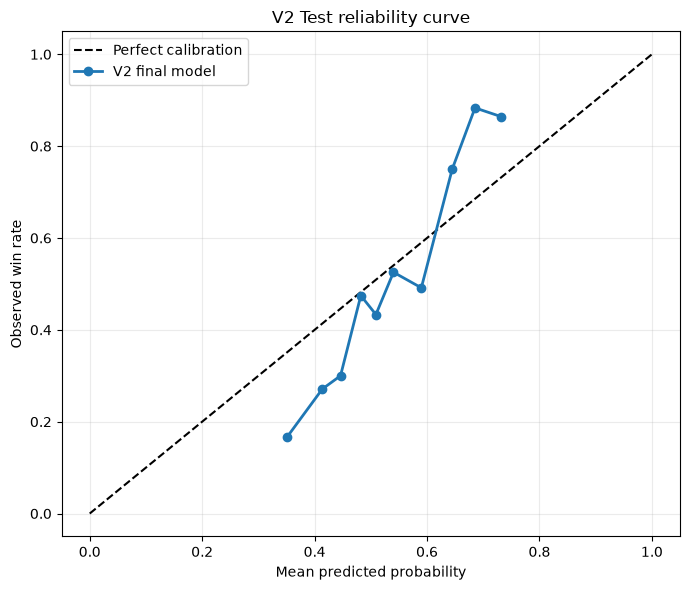

In [14]:
observed_rate, predicted_mean = calibration_curve(y_test, test_probability, n_bins=10, strategy="quantile")
calibration_table = pd.DataFrame({
    "mean_predicted_probability": predicted_mean, "observed_win_rate": observed_rate,
})
display(calibration_table)
figure, axis = plt.subplots(figsize=(7, 6))
axis.plot([0, 1], [0, 1], "--", color="black", label="Perfect calibration")
axis.plot(predicted_mean, observed_rate, marker="o", linewidth=2, label="V2 final model")
axis.set(xlabel="Mean predicted probability", ylabel="Observed win rate", title="V2 Test reliability curve")
axis.legend(); axis.grid(alpha=0.25); figure.tight_layout(); plt.show()

## IEM Cologne 2026 and Falcons–FURIA audit

The tournament is isolated only after the global Test vector is frozen. Falcons probabilities are orientation-corrected row by row. We report every map probability and their mean next to the V1 series forecast of 70.38%, while explicitly treating them as different estimands.

## ביקורת IEM Cologne 2026 ו־Falcons–FURIA

הטורניר מבודד רק לאחר שווקטור Test הכולל הוקפא. הסתברויות Falcons מתוקנות לפי כיוון כל שורה. אנו מדווחים כל הסתברות מפה ואת ממוצען לצד תחזית הסדרה של V1, שעמדה על 70.38%, תוך הבהרה שמדובר באומדים שונים.

In [15]:
test_tournament_text = test_model_frame["tournament"].fillna("").astype(str)
cologne_mask = test_tournament_text.str.contains("cologne", case=False, regex=False).to_numpy()
assert int(cologne_mask.sum()) == 187, f"Expected 187 Cologne rows, found {int(cologne_mask.sum())}."
COLOGNE_METRICS = metric_triplet(y_test[cologne_mask], test_probability[cologne_mask])
print("IEM Cologne 2026 metrics:")
for metric, value in COLOGNE_METRICS.items(): print(f"  {metric}: {value:.12f}")

team1_keys = test_model_frame["team1_join_key"].fillna("").astype(str).str.casefold()
team2_keys = test_model_frame["team2_join_key"].fillna("").astype(str).str.casefold()
falcons_furia_mask = cologne_mask & (
    ((team1_keys == "falcons") & (team2_keys == "furia"))
    | ((team1_keys == "furia") & (team2_keys == "falcons"))
).to_numpy()
assert falcons_furia_mask.any(), "Falcons vs FURIA rows were not found in Cologne."
falcons_probability = np.where(
    team1_keys.to_numpy()[falcons_furia_mask] == "falcons",
    test_probability[falcons_furia_mask], 1.0 - test_probability[falcons_furia_mask],
)
falcons_rows = test_model_frame.loc[
    falcons_furia_mask,
    ["datetime", "match_id", "game_id", "map_name", "team1", "team2", "team1_win"],
].copy()
falcons_rows["falcons_win_probability"] = falcons_probability
FALCONS_MEAN_MAP_PROBABILITY = float(falcons_probability.mean())
display(falcons_rows)
print(f"Falcons mean map-win probability across isolated rows: {FALCONS_MEAN_MAP_PROBABILITY:.12f}")
print("V1 series-win reference: 0.703800000000")

IEM Cologne 2026 metrics:
  log_loss: 0.608109116554
  accuracy: 0.689839572193
  brier: 0.209203869104


,datetime,match_id,game_id,map_name,team1,team2,team1_win,falcons_win_probability
592,2026-06-21 18:00:00,7302876,154157.0,Mirage,Team Falcons,FURIA Esports,1,0.636073
593,2026-06-21 18:00:00,7302876,154158.0,Anubis,Team Falcons,FURIA Esports,1,0.637031
594,2026-06-21 18:00:00,7302876,154159.0,Inferno,Team Falcons,FURIA Esports,1,0.679642


Falcons mean map-win probability across isolated rows: 0.650915205479
V1 series-win reference: 0.703800000000


## Reproducible artifact and results ledger

The fitted model, ordered feature contract, preprocessing constants, selected configuration, and validation guardrail are serialized together. SHA-256 fingerprints the deployed bytes. The metadata sidecar records the immutable Test results, and `docs/RESULTS.md` receives a bilingual V1-versus-V2 comparison.

## ארטיפקט ניתן לשחזור ופנקס תוצאות

המודל המאומן, חוזה סדר הפיצ'רים, קבועי הקדם־עיבוד, התצורה שנבחרה ומחסום הוולידציה נשמרים יחד. SHA-256 מטביע חתימה על הבתים שנפרסו. קובץ המטא־דאטה מתעד את תוצאות Test הבלתי־משתנות, ו־`docs/RESULTS.md` מקבל השוואה דו־לשונית בין V1 ל־V2.

In [16]:
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "map_classifier"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_PATH = ARTIFACT_DIR / "v2_dynamic_hybrid_xgboost.joblib"
METADATA_PATH = ARTIFACT_DIR / "v2_dynamic_hybrid_xgboost.metadata.json"
artifact_bundle = {
    "model": final_model,
    "feature_columns": list(WINNING_FEATURES),
    "locked_model_name": LOCKED_MODEL_NAME,
    "locked_hyperparameters": locked_hyperparameters,
    "n_estimators": locked_n_estimators,
    "player_half_life_days": OPTIMAL_PLAYER_HALF_LIFE_DAYS,
    "k_perf": OPTIMAL_K_PERF,
    "player_scale_factor": PLAYER_SCALE_FACTOR,
    "hybrid_weight": FINAL_W,
    "validation_guardrail": {
        "paired_log_loss_delta_tuned_minus_untuned": MODEL_DELTA_MEAN,
        "ci95_low": float(MODEL_DELTA_CI_LOW), "ci95_high": float(MODEL_DELTA_CI_HIGH),
        "optuna_passed": OPTUNA_PASSES_GUARDRAIL,
        "bootstrap_iterations": 5000, "cluster_unit": "match_id",
    },
    "no_decay_boundary_probe": {
        "validation_log_loss": NO_DECAY_VALIDATION_LOG_LOSS,
        "validation_correlation": NO_DECAY_VALIDATION_CORRELATION,
        "train_fitted_scale": NO_DECAY_SCALE_FACTOR,
        "selected_1095_day_result_remains_preferable": DECAY_PLATEAU_CONFIRMED,
    },
}
artifact_temp = ARTIFACT_PATH.with_suffix(ARTIFACT_PATH.suffix + ".tmp")
joblib.dump(artifact_bundle, artifact_temp)
artifact_temp.replace(ARTIFACT_PATH)
artifact_sha256 = hashlib.sha256(ARTIFACT_PATH.read_bytes()).hexdigest()

def make_json_safe(value):
    if isinstance(value, dict): return {str(key): make_json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)): return [make_json_safe(item) for item in value]
    if isinstance(value, (np.integer,)): return int(value)
    if isinstance(value, (np.floating,)): return float(value)
    return value

metadata = make_json_safe({
    "schema_version": "2.0.0",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "artifact": str(ARTIFACT_PATH.relative_to(PROJECT_ROOT)).replace("\\", "/"),
    "sha256": artifact_sha256,
    "test_policy": "single predict_proba call on 595 locked natural-order rows",
    "test_metrics": {
        "rows": len(test_model_frame), "log_loss": TEST_LOG_LOSS,
        "accuracy": TEST_ACCURACY, "brier": TEST_BRIER,
        "map_1": test_strata_metrics.loc["Map 1"].to_dict(),
        "map_2_plus": test_strata_metrics.loc["Map 2+"].to_dict(),
        "iem_cologne_2026_rows": int(cologne_mask.sum()),
        "iem_cologne_2026": COLOGNE_METRICS,
        "falcons_furia_rows": int(falcons_furia_mask.sum()),
        "falcons_mean_map_probability": FALCONS_MEAN_MAP_PROBABILITY,
        "v1_falcons_series_reference": 0.7038,
    },
})
metadata_temp = METADATA_PATH.with_suffix(METADATA_PATH.suffix + ".tmp")
metadata_temp.write_text(json.dumps(metadata, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
metadata_temp.replace(METADATA_PATH)

results_path = PROJECT_ROOT / "docs" / "RESULTS.md"
existing_results = results_path.read_text(encoding="utf-8") if results_path.exists() else "# Results / תוצאות\n"
start_marker, end_marker = "<!-- V2_FINAL_RESULTS_START -->", "<!-- V2_FINAL_RESULTS_END -->"
if start_marker in existing_results and end_marker in existing_results:
    prefix = existing_results.split(start_marker, 1)[0].rstrip()
    suffix = existing_results.split(end_marker, 1)[1].lstrip()
    existing_results = prefix + ("\n\n" + suffix if suffix else "")

v2_section = f"""{start_marker}
## Version 2.0 final locked Test / מבחן סופי נעול של גרסה 2.0

### English

Model selection was completed before Test. The match-cluster bootstrap 95% CI for tuned-minus-untuned Validation row loss was `[{MODEL_DELTA_CI_LOW:.6f}, {MODEL_DELTA_CI_HIGH:.6f}]`; therefore `{LOCKED_MODEL_NAME}` was locked. Test was scored exactly once on 595 natural-order map rows.

The no-decay boundary probe produced Validation Log-loss `{NO_DECAY_VALIDATION_LOG_LOSS:.6f}` versus `{PLAYER_ONLY_LOG_LOSS:.6f}` at 1,095 days, confirming that disabling decay does not improve the selected Player-Elo setting.

| Version | Accuracy | Log-loss | Brier |
|---|---:|---:|---:|
| V1 deployed calibrated model | 0.666387 | 0.646857 | 0.214199 |
| V2 Dynamic Hybrid final | {TEST_ACCURACY:.6f} | {TEST_LOG_LOSS:.6f} | {TEST_BRIER:.6f} |

| V2 Test stratum | Rows | Accuracy (95% cluster CI) | Log-loss (95% cluster CI) | Brier (95% cluster CI) |
|---|---:|---:|---:|---:|
| Map 1 | {int(test_strata_metrics.loc['Map 1', 'rows'])} | {test_strata_metrics.loc['Map 1', 'accuracy']:.6f} ({stratum_intervals['Map 1']['accuracy'][0]:.6f}, {stratum_intervals['Map 1']['accuracy'][1]:.6f}) | {test_strata_metrics.loc['Map 1', 'log_loss']:.6f} ({stratum_intervals['Map 1']['log_loss'][0]:.6f}, {stratum_intervals['Map 1']['log_loss'][1]:.6f}) | {test_strata_metrics.loc['Map 1', 'brier']:.6f} ({stratum_intervals['Map 1']['brier'][0]:.6f}, {stratum_intervals['Map 1']['brier'][1]:.6f}) |
| Map 2+ | {int(test_strata_metrics.loc['Map 2+', 'rows'])} | {test_strata_metrics.loc['Map 2+', 'accuracy']:.6f} ({stratum_intervals['Map 2+']['accuracy'][0]:.6f}, {stratum_intervals['Map 2+']['accuracy'][1]:.6f}) | {test_strata_metrics.loc['Map 2+', 'log_loss']:.6f} ({stratum_intervals['Map 2+']['log_loss'][0]:.6f}, {stratum_intervals['Map 2+']['log_loss'][1]:.6f}) | {test_strata_metrics.loc['Map 2+', 'brier']:.6f} ({stratum_intervals['Map 2+']['brier'][0]:.6f}, {stratum_intervals['Map 2+']['brier'][1]:.6f}) |

IEM Cologne 2026 (187 rows): Accuracy `{COLOGNE_METRICS['accuracy']:.6f}`, Log-loss `{COLOGNE_METRICS['log_loss']:.6f}`, Brier `{COLOGNE_METRICS['brier']:.6f}`. Falcons' mean map-win probability in the isolated Falcons–FURIA rows is `{FALCONS_MEAN_MAP_PROBABILITY:.6f}`; the V1 series-win reference was `0.703800`, so these are distinct estimands.

Artifact SHA-256: `{artifact_sha256}`.

### עברית

המודל נבחר לפני פתיחת Test. רווח הסמך 95% ב־Bootstrap לפי אשכולות משחק עבור הפרש הפסד השורה המכוונן פחות הלא־מכוונן ב־Validation היה `[{MODEL_DELTA_CI_LOW:.6f}, {MODEL_DELTA_CI_HIGH:.6f}]`; לכן ננעלה התצורה `{LOCKED_MODEL_NAME}`. Test חושב פעם אחת בלבד על 595 שורות מפה בסדר הטבעי.

בדיקת הגבול ללא דעיכה הפיקה Validation Log-loss של `{NO_DECAY_VALIDATION_LOG_LOSS:.6f}` לעומת `{PLAYER_ONLY_LOG_LOSS:.6f}` ב־1,095 ימים, ולכן ביטול הדעיכה אינו משפר את תצורת Player Elo שנבחרה.

הטבלה באנגלית לעיל היא הרשומה הקנונית. IEM Cologne 2026 כולל 187 שורות: דיוק `{COLOGNE_METRICS['accuracy']:.6f}`, Log-loss `{COLOGNE_METRICS['log_loss']:.6f}` ו־Brier `{COLOGNE_METRICS['brier']:.6f}`. הסתברות הניצחון הממוצעת של Falcons ברמת מפה בשורות Falcons–FURIA היא `{FALCONS_MEAN_MAP_PROBABILITY:.6f}`; תחזית V1 הייתה הסתברות סדרה של `0.703800`, ולכן אלו אומדים שונים.
{end_marker}
"""
results_path.write_text(existing_results.rstrip() + "\n\n" + v2_section, encoding="utf-8")
print(f"Saved artifact: {ARTIFACT_PATH}")
print(f"Artifact SHA-256: {artifact_sha256}")
print(f"Saved metadata: {METADATA_PATH}")
print(f"Updated results ledger: {results_path}")

Saved artifact: C:\Users\yitsh\Documents\Paython_Projects\Kaggle\CS2 AI Model\project\artifacts\map_classifier\v2_dynamic_hybrid_xgboost.joblib
Artifact SHA-256: e3628145a51f831842556e2c68c709a685524b332ca6bcfebf4169f23bd73bbb
Saved metadata: C:\Users\yitsh\Documents\Paython_Projects\Kaggle\CS2 AI Model\project\artifacts\map_classifier\v2_dynamic_hybrid_xgboost.metadata.json
Updated results ledger: C:\Users\yitsh\Documents\Paython_Projects\Kaggle\CS2 AI Model\project\docs\RESULTS.md


## Stop point

Version 2.0 is frozen. Model selection was resolved on Validation, the Test probability vector was generated exactly once, and all downstream diagnostics were computed without refitting or revisiting Test labels.

## נקודת עצירה

גרסה 2.0 מוקפאת. בחירת המודל הוכרעה על Validation, וקטור הסתברויות Test נוצר בדיוק פעם אחת, וכל האבחונים בהמשך חושבו ללא אימון מחדש וללא חזרה לתוויות Test.